# 1.4 — Разбиение на обучающую, валидационную и тестовую выборки

**Папка 1, подноутбук 4.** Стратифицированное разбиение benchmark на train/val/test по
тройке (тип грунта × режим нагружения × метка разжижения). Проверяется сбалансированность,
разбиение сохраняется в `data/`. Рисунки и таблицы — на английском.

## Окружение и загрузка артефакта

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "demo_run"
MODELS_DIR = REPO_ROOT / "models"

import json
from liquefaction_ai import load_population_artifact
from liquefaction_ai.constants import SOIL_DISPLAY_NAMES_EN, SOIL_NAMES
from liquefaction_ai.viz import bar, grouped_bar

population, config = load_population_artifact(DATA_DIR)
meta = population["meta"]; soil_order = list(SOIL_NAMES)
soil_present = [s for s in soil_order if (meta["soil_type"] == s).any()]
benchmark = population["benchmark"]
bench_idx = np.asarray(benchmark["benchmark_idx"])
train_abs = bench_idx[np.asarray(benchmark["train_rel"])]
val_abs = bench_idx[np.asarray(benchmark["val_rel"])]
test_abs = bench_idx[np.asarray(benchmark["test_rel"])]
print("benchmark:", len(bench_idx), "| train/val/test:", len(train_abs), len(val_abs), len(test_abs))

benchmark: 666 | train/val/test: 466 99 101


## Размеры выборок

,Split,Size,Fraction
0,Train,466,0.700
1,Validation,99,0.149
2,Test,101,0.152


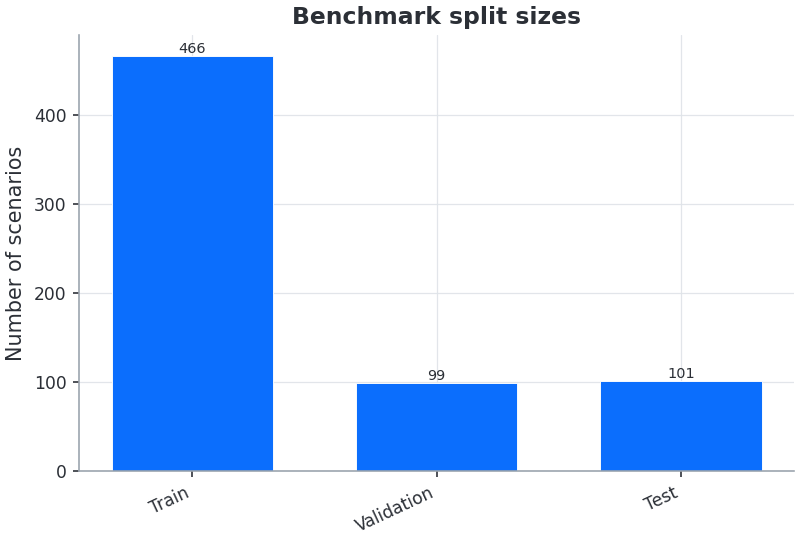

In [2]:
sizes = pd.DataFrame({"Split": ["Train", "Validation", "Test"],
    "Size": [len(train_abs), len(val_abs), len(test_abs)],
    "Fraction": [round(len(train_abs)/len(bench_idx), 3), round(len(val_abs)/len(bench_idx), 3),
                 round(len(test_abs)/len(bench_idx), 3)]})
display(sizes)
bar(sizes["Split"], sizes["Size"], title="Benchmark split sizes", ylabel="Number of scenarios",
    text_fmt=".0f", color="#0b6efd", save=SAVE_FIGS, fig_id="1_4_split_sizes").show()

## Проверка сбалансированности страт

,Split,Size,Liquefaction rate,Gravelly sand,Coarse sand,Medium sand,Fine sand,Silty sand,Sandy loam,Loam,Clay
0,Train,466,0.6073,0.013,0.101,0.146,0.124,0.041,0.060,0.255,0.260
1,Validation,99,0.6061,0.010,0.081,0.152,0.131,0.101,0.071,0.222,0.232
2,Test,101,0.6139,0.000,0.139,0.158,0.168,0.079,0.059,0.228,0.168


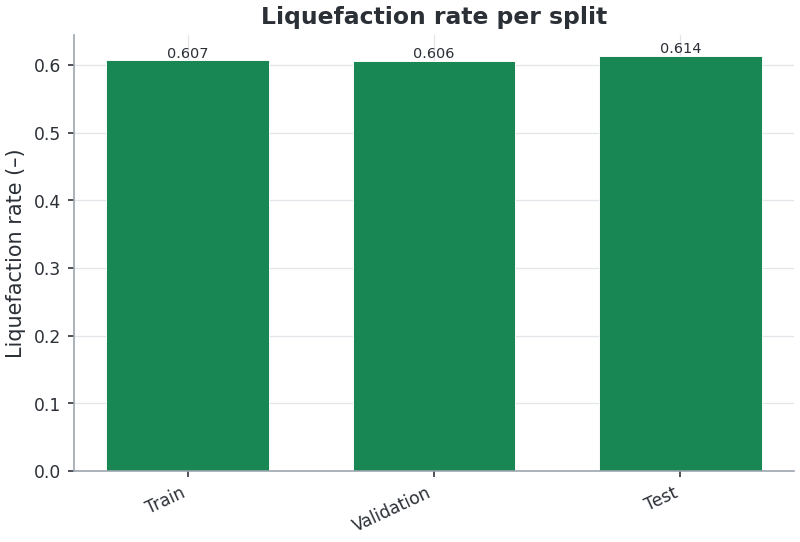

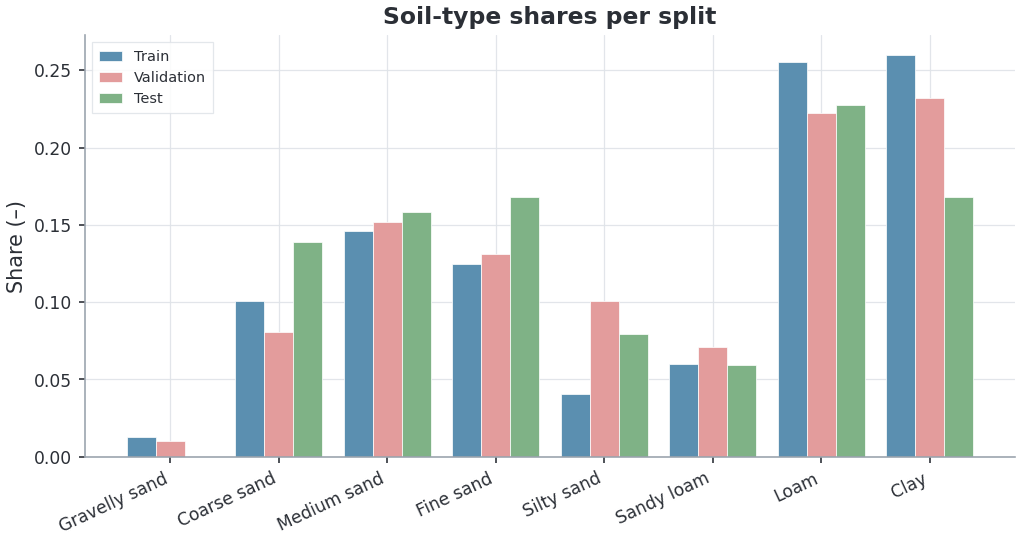

In [3]:
def profile(abs_idx, name):
    sub = meta.iloc[abs_idx]
    row = {"Split": name, "Size": len(sub), "Liquefaction rate": round(float(sub["liq_label"].mean()), 4)}
    for s in soil_present:
        row[SOIL_DISPLAY_NAMES_EN[s]] = round(float((sub["soil_type"] == s).mean()), 3)
    return row
names = ["Train", "Validation", "Test"]; abs_sets = [train_abs, val_abs, test_abs]
display(pd.DataFrame([profile(ix, nm) for ix, nm in zip(abs_sets, names)]))
bar(names, [meta.iloc[ix]["liq_label"].mean() for ix in abs_sets], title="Liquefaction rate per split",
    ylabel="Liquefaction rate (–)", color="#198754", save=SAVE_FIGS, fig_id="1_4_split_liqrate").show()
shares = {nm: [(meta.iloc[ix]["soil_type"] == s).mean() for s in soil_present] for nm, ix in zip(names, abs_sets)}
grouped_bar([SOIL_DISPLAY_NAMES_EN[s] for s in soil_present], shares,
            title="Soil-type shares per split", ylabel="Share (–)",
            save=SAVE_FIGS, fig_id="1_4_split_soil_shares").show()

## Сохранение разбиения в `data/`

In [4]:
payload = {
    "seed": int(config.seed), "benchmark_subset": int(len(bench_idx)),
    "train_fraction": float(config.benchmark_train_fraction), "val_fraction": float(config.benchmark_val_fraction),
    "benchmark_idx": [int(i) for i in bench_idx],
    "train_rel": [int(i) for i in np.asarray(benchmark["train_rel"])],
    "val_rel": [int(i) for i in np.asarray(benchmark["val_rel"])],
    "test_rel": [int(i) for i in np.asarray(benchmark["test_rel"])],
    "train_abs": [int(i) for i in train_abs], "val_abs": [int(i) for i in val_abs], "test_abs": [int(i) for i in test_abs],
    "liq_rate": {"train": float(meta.iloc[train_abs]["liq_label"].mean()),
                 "val": float(meta.iloc[val_abs]["liq_label"].mean()),
                 "test": float(meta.iloc[test_abs]["liq_label"].mean())}}
(DATA_DIR / "splits.json").write_text(json.dumps(payload, indent=2), encoding="utf-8")
print("Splits saved to:", DATA_DIR / "splits.json")

Splits saved to: /sessions/zealous-kind-sagan/mnt/liquefaction-ai/data/demo_run/splits.json


## Итог

Разбиение зафиксировано. Следующий шаг — **папка 2: обучение моделей**.